# Titanic - machine learning from disaster project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score

In [ ]:
da_ta = pd.read_csv(r'path\train.csv')

In [3]:
da_ta.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
da_ta['Age'] = da_ta['Age'].fillna(da_ta['Age'].median())
da_ta.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Text(0.5, 1.0, 'Women And Children First! ')

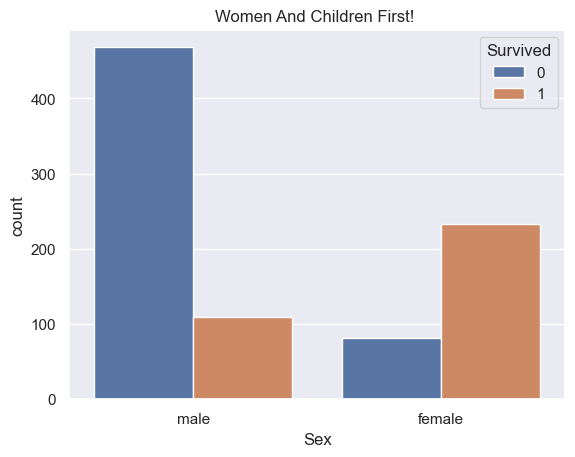

In [5]:
sns.countplot(x= 'Sex', hue='Survived', data = da_ta)
plt.title('Women And Children First! ')

Text(0.5, 1.0, 'Women and Children first!')

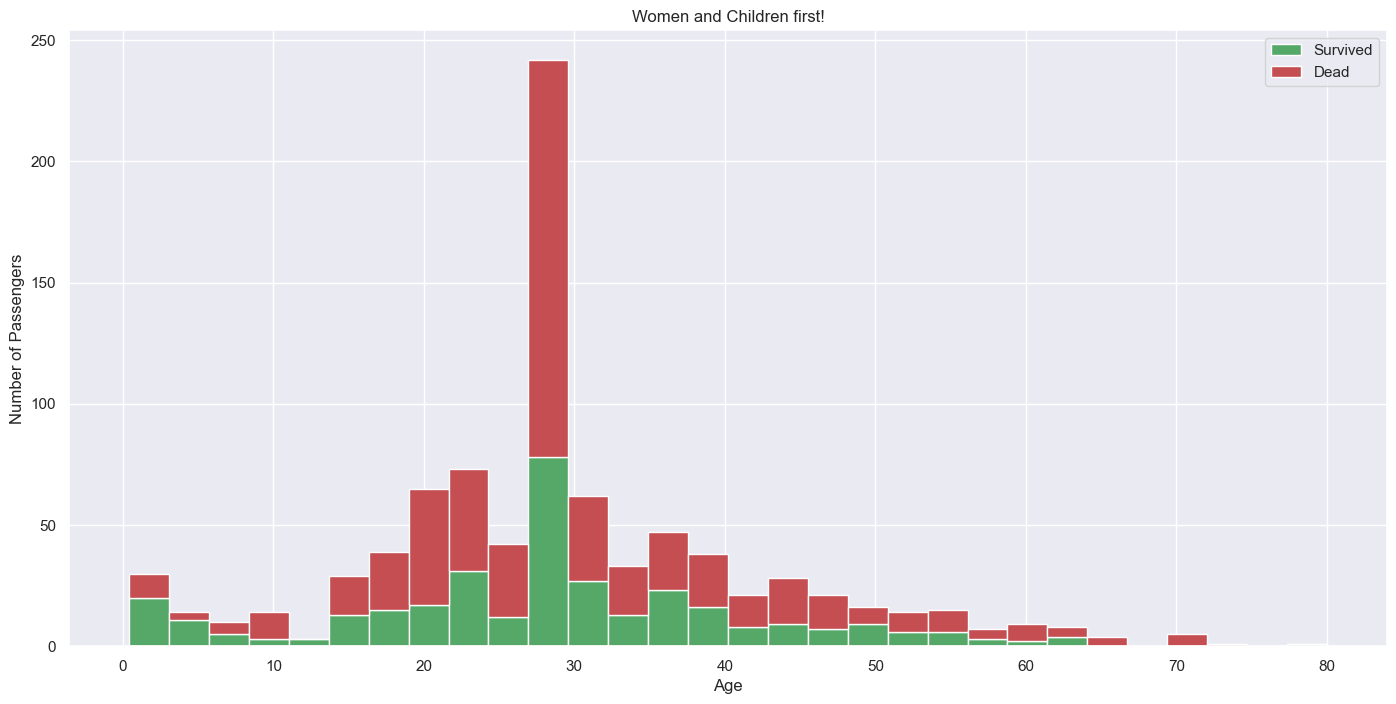

In [6]:
figure = plt.figure(figsize=(17,8))
plt.hist([da_ta[da_ta['Survived']==1]['Age'], da_ta[da_ta['Survived']==0]['Age']],color=['g','r'], stacked=True, bins = 30, label = ['Survived','Dead'])
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend()
plt.title('Women and Children first!')

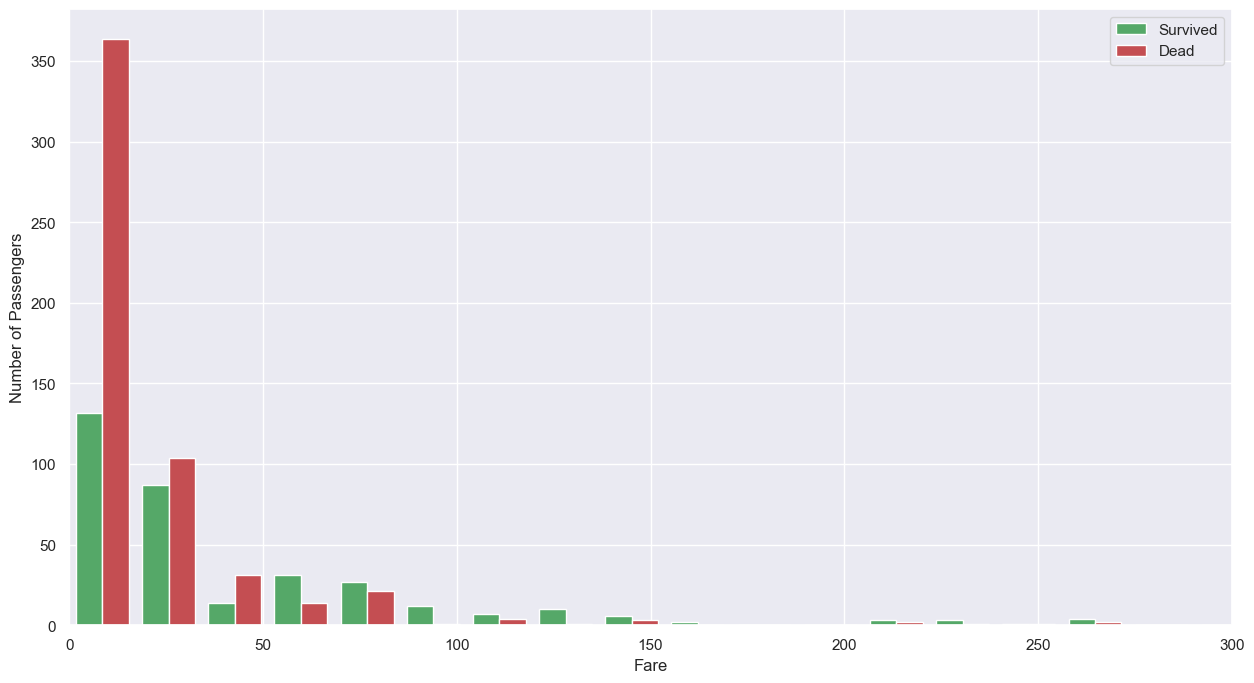

In [7]:
figure = plt.figure(figsize=(15,8))
plt.hist([da_ta[da_ta['Survived']==1]['Fare'],
          da_ta[da_ta['Survived']==0]['Fare']], color=['g','r'], 
         bins = 30,label = ['Survived','Dead'])
plt.xlabel('Fare')
plt.xlim([0,300])
plt.ylabel('Number of Passengers')
plt.legend()

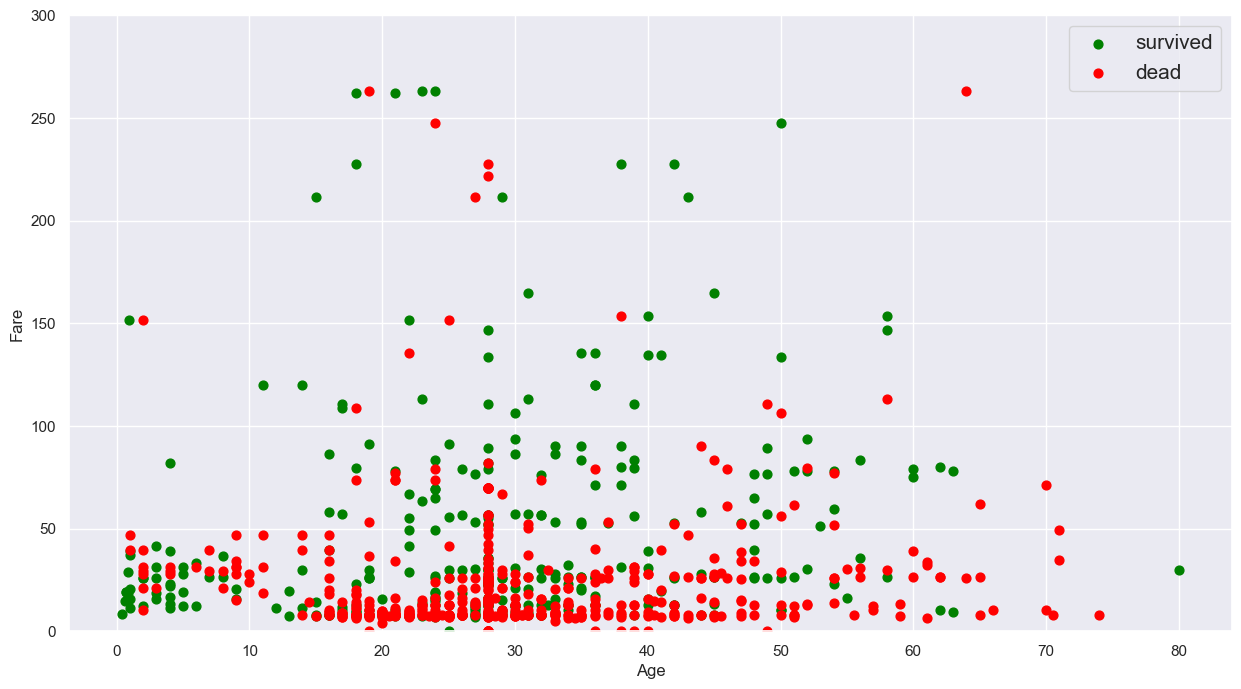

In [8]:
plt.figure(figsize=(15,8))
ax = plt.subplot()
ax.scatter(da_ta[da_ta['Survived']==1]['Age'],da_ta[da_ta['Survived']==1]['Fare'], c='green',s=40)
ax.scatter(da_ta[da_ta['Survived']==0]['Age'],da_ta[da_ta['Survived']==0]['Fare'], c='red',s=40)
ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_ylim([0,300])
ax.legend(('survived','dead'),scatterpoints=1,loc='upper right',fontsize=15,)

<Axes: xlabel='Embarked', ylabel='count'>

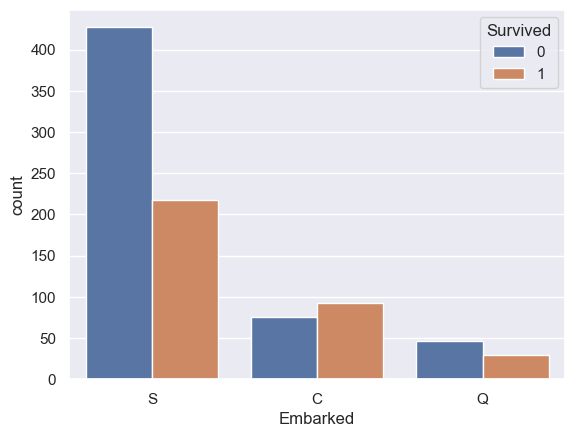

In [9]:
sns.countplot(x='Embarked', hue='Survived', data=da_ta)

In [ ]:
train = pd.read_csv(r'path\train.csv')
test = pd.read_csv(r'path.csv')
targets = train.Survived
train.drop('Survived', axis = 1, inplace=True)
combined = pd.concat([train, test], ignore_index = True)

In [11]:
Title_Dictionary = {"Capt":       "Officer",
                    "Col":        "Officer",
                    "Major":      "Officer",
                    "Jonkheer":   "Royalty",
                    "Don":        "Royalty",
                    "Sir" :       "Royalty",
                    "Dr":         "Officer",
                    "Rev":        "Officer",
                    "the Countess":"Royalty",
                    "Dona":       "Royalty",
                    "Mme":        "Mrs",
                    "Mlle":       "Miss",
                    "Ms":         "Mrs",
                    "Lady" :      "Royalty"}
combined['Title'] = combined['Name'].map(lambda name:name.split(',')[1].split('.')[0].strip())
combined['Title'] = combined.Title.apply(lambda x:Title_Dictionary.get(x,x))


In [12]:
grouped_median_train = grouped_median = (
    combined.iloc[:len(train)]
    .groupby(['Sex','Pclass','Title'])['Age']
    .median()
)
grouped_median_test = grouped_median = (
    combined.iloc[:len(train)]
    .groupby(['Sex','Pclass','Title'])['Age']
    .median()
)

In [13]:
combined.drop('Name', axis=1, inplace=True)
le_title = LabelEncoder()
combined['Title'] = le_title.fit_transform(combined['Title'])

In [14]:
combined["Fare"] = combined["Fare"].fillna(combined["Fare"].mean())
combined["Embarked"] = combined["Embarked"].fillna("S")
le_embarked = LabelEncoder()
combined['Embarked'] = le_embarked.fit_transform(combined['Embarked'])
combined["Cabin"] = combined["Cabin"].fillna("U")
combined["Cabin"] = combined["Cabin"].astype(str).str[0]
le_cabin = LabelEncoder()
combined['Cabin'] = le_cabin.fit_transform(combined['Cabin'])
le_sex = LabelEncoder()
combined['Sex'] = le_sex.fit_transform(combined['Sex'])

In [15]:
def cleanTicket(ticket):
    ticket = ticket.replace('.','')
    ticket = ticket.replace('/','')
    ticket = ticket.split()
    ticket = list(map(lambda t : t.strip(), ticket))
    ticket = list(filter(lambda t : not t.isdigit(), ticket))
    if len(ticket) > 0:
        return ticket[0]
    else: 
        return 'XXX'

In [16]:
combined['Ticket'] = combined['Ticket'].apply(cleanTicket)
le_ticket = LabelEncoder()
combined['Ticket'] = le_ticket.fit_transform(combined['Ticket'])


In [17]:
combined['FamilySize'] = combined['Parch'] + combined['SibSp'] + 1
combined['Singleton'] = combined['FamilySize'].map(lambda s: 1 if s == 1 else 0)
combined['SmallFamily'] = combined['FamilySize'].map(lambda s: 1 if 2<=s<=4 else 0)
combined['LargeFamily'] = combined['FamilySize'].map(lambda s: 1 if 5<=s else 0)

combined.drop('PassengerId', inplace=True, axis=1)

In [18]:
X_train = combined.head(len(train))
X_test = combined[len(train):]
y_train = da_ta.Survived

In [19]:
def compute_score(clf, X, y, scoring='accuracy'):
    xval = cross_val_score(clf, X, y, cv = 5, scoring=scoring)
    return np.mean(xval)

In [20]:
clf = RandomForestClassifier(n_estimators=50, max_features='sqrt')
clf = clf.fit(X_train, y_train)

In [21]:
model = SelectFromModel(clf, prefit=True)
train_reduced = model.transform(X_train)
test_reduced = model.transform(X_test)
train_reduced.shape, X_train.shape

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


((891, 4), (891, 14))

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

# turn run_gs to True if you want to run the gridsearch again.
run_gs = False

if run_gs:
    parameter_grid = {
                 'max_depth' : [4, 6, 8],
                 'n_estimators': [50, 10],
                 'max_features': ['sqrt', 'auto', 'log2'],
                 'min_samples_split': [2, 3, 10],
                 'min_samples_leaf': [1, 3, 10],
                 'bootstrap': [True, False],
                 }
    forest = RandomForestClassifier()
    cross_validation = StratifiedKFold(y_train, n_folds=5)

    grid_search = GridSearchCV(forest,
                               scoring='accuracy',
                               param_grid=parameter_grid,
                               cv=cross_validation)

    grid_search.fit(train_reduced, y_train)
    model = grid_search
    parameters = grid_search.best_params_

    print('Best score: {}'.format(grid_search.best_score_))
    print('Best parameters: {}'.format(grid_search.best_params_))
else: 
    parameters = {'bootstrap': False, 'min_samples_leaf': 3, 'n_estimators': 50, 
                  'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 6}
    model = RandomForestClassifier(**parameters)
    model.fit(train_reduced, y_train)
    

In [23]:
compute_score(model, train_reduced, y_train, scoring='accuracy')

np.float64(0.7923545289059069)

In [ ]:
output = model.predict(test_reduced).astype(int)
df_output = pd.DataFrame()
aux = pd.read_csv(r'path\test.csv')
df_output['PassengerId'] = aux['PassengerId']
df_output['Survived'] = output
df_output[['PassengerId','Survived']].to_csv(r'path\titanic_survivors_datasheet.csv',index=False)

In [25]:
model.score(train_reduced, y_train)

0.8507295173961841